# Monitoring du modèle de scoring crédit — Analyse du Data Drift

## Objectif

Comparer la distribution des features entre:
- **Baseline (données d'entraînement)**: `data/drift_baseline.parquet` — 10,000 clients
- **Production (données collectées)**: `logs/api_logs.jsonl` — requêtes en temps réel

Utilisation de **Evidently AI** pour détecter les dérives de données (data drift) et les problèmes de qualité.

## 1. Imports et Configuration

In [21]:
import json
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ Numpy version: {np.__version__}")
print(f"✓ Imports successful")

✓ Pandas version: 3.0.2
✓ Numpy version: 2.4.4
✓ Imports successful


## 2. Chargement de la Baseline (Données de Référence)

In [22]:
# Load reference baseline data
baseline_path = Path("../data/drift_baseline.parquet")

if not baseline_path.exists():
    raise FileNotFoundError(f"❌ Baseline file not found: {baseline_path}")

reference_df = pd.read_parquet(baseline_path)

print(f"✓ Baseline loaded successfully")
print(f"  Shape: {reference_df.shape}")
print(f"  Memory usage: {reference_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n📊 First few rows:")
print(reference_df.head())
print(f"\n📋 Data types and info:")
print(reference_df.info())

✓ Baseline loaded successfully
  Shape: (10000, 146)
  Memory usage: 12.48 MB

📊 First few rows:
       NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  \
245895         Cash loans           M            Y               N   
98194          Cash loans           F            Y               Y   
36463          Cash loans           F            Y               N   
249923         Cash loans           F            N               Y   
158389         Cash loans           M            N               Y   

        CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
245895             2          207000.0    465457.5      52641.0   
98194              0          247500.0   1281712.5      48946.5   
36463              0          202500.0    495000.0      39109.5   
249923             0          247500.0    254700.0      24939.0   
158389             0          112500.0    308133.0      15862.5   

        AMT_GOODS_PRICE NAME_TYPE_SUITE  ... installments_mean  payment_sum  \


## 3. Chargement des Logs de Production (API Logs)

In [23]:
# Load production logs from JSONL file
logs_path = Path("../logs/api_logs.jsonl")

if not logs_path.exists():
    print(f"⚠️  No logs found at {logs_path}")
    print(f"   Run scripts/simulate_traffic.py to generate logs first")
    production_df = pd.DataFrame()
    production_metrics_df = pd.DataFrame()
else:
    # Parse JSONL file
    logs_data = []
    metrics_data = []
    
    with open(logs_path, 'r') as f:
        for line in f:
            try:
                entry = json.loads(line.strip())
                # Extract features
                if 'features' in entry:
                    feature_row = entry['features'].copy()
                    logs_data.append(feature_row)
                    
                    # Extract metrics
                    metrics_data.append({
                        'client_id': entry.get('client_id'),
                        'score': entry.get('score'),
                        'prediction': entry.get('prediction'),
                        'threshold': entry.get('threshold'),
                        'inference_time_ms': entry.get('inference_time_ms'),
                        'timestamp': entry.get('timestamp')
                    })
            except json.JSONDecodeError as e:
                print(f"⚠️  Skipped invalid JSON line")
                continue
    
    if logs_data:
        production_df = pd.DataFrame(logs_data)
        production_metrics_df = pd.DataFrame(metrics_data)
        
        print(f"✓ Production logs loaded successfully")
        print(f"  Total logged requests: {len(production_df)}")
        print(f"  Features captured: {production_df.shape[1]}")
        print(f"  Memory usage: {production_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
        
        if len(production_metrics_df) > 0:
            print(f"\n📅 Time coverage:")
            print(f"  First request: {production_metrics_df['timestamp'].min()}")
            print(f"  Last request: {production_metrics_df['timestamp'].max()}")
            print(f"\n📊 Metrics summary:")
            print(production_metrics_df[['score', 'inference_time_ms', 'prediction']].describe())
    else:
        print(f"⚠️  No valid logs found in {logs_path}")
        print(f"   Run scripts/simulate_traffic.py to generate logs first")
        production_df = pd.DataFrame()
        production_metrics_df = pd.DataFrame()

✓ Production logs loaded successfully
  Total logged requests: 370
  Features captured: 146
  Memory usage: 0.46 MB

📅 Time coverage:
  First request: 2026-04-07 17:39:47
  Last request: 2026-04-07 18:29:45

📊 Metrics summary:
            score  inference_time_ms  prediction
count  370.000000         370.000000  370.000000
mean     0.392816          75.064687    0.289189
std      0.185849         238.781341    0.454000
min      0.041308          33.520937    0.000000
25%      0.233174          38.647592    0.000000
50%      0.373241          41.032195    0.000000
75%      0.536646          44.597328    1.000000
max      0.852653        2592.156172    1.000000


## 4. Vérification de l'Alignement des Colonnes

In [24]:
if len(production_df) > 0:
    baseline_cols = set(reference_df.columns)
    production_cols = set(production_df.columns)
    
    print(f"📋 Column Alignment Check")
    print(f"  Baseline features: {len(baseline_cols)}")
    print(f"  Production features: {len(production_cols)}")
    
    missing_in_prod = baseline_cols - production_cols
    extra_in_prod = production_cols - baseline_cols
    
    if missing_in_prod:
        print(f"\n⚠️  Missing in production ({len(missing_in_prod)}):")
        print(f"  {sorted(missing_in_prod)[:5]}...")  # Show first 5
    
    if extra_in_prod:
        print(f"\n⚠️  Extra in production ({len(extra_in_prod)}):")
        print(f"  {sorted(extra_in_prod)}")
    
    if not missing_in_prod and not extra_in_prod:
        print(f"\n✓ Perfect alignment! {len(baseline_cols)} features match exactly")
    
    # Ensure production_df has same columns as reference_df in same order
    common_cols = baseline_cols & production_cols
    production_df_aligned = production_df[list(common_cols)]
    reference_df_aligned = reference_df[list(common_cols)]
    
    print(f"\n✓ Using {len(common_cols)} common features for drift analysis")
else:
    print("⚠️  No production data to align")
    reference_df_aligned = reference_df
    production_df_aligned = pd.DataFrame()

📋 Column Alignment Check
  Baseline features: 146
  Production features: 146

✓ Perfect alignment! 146 features match exactly

✓ Using 146 common features for drift analysis


## 5. Rapport Evidently — Data Drift

In [25]:
if len(production_df_aligned) > 0:
    reports_dir = Path("../reports")
    reports_dir.mkdir(exist_ok=True)
    
    print("🔍 Generating Drift Analysis Report...")
    
    # Calculate basic drift statistics (only for numeric columns)
    drift_report_data = []
    for column in common_cols:
        baseline_vals = reference_df_aligned[column].dropna()
        production_vals = production_df_aligned[column].dropna()
        
        # Skip non-numeric columns
        if baseline_vals.dtype == 'object' or production_vals.dtype == 'object':
            continue
        
        if len(baseline_vals) > 0 and len(production_vals) > 0:
            try:
                baseline_mean = float(baseline_vals.mean())
                production_mean = float(production_vals.mean())
                diff_pct = abs(production_mean - baseline_mean) / abs(baseline_mean) * 100 if baseline_mean != 0 else 0
                
                drift_report_data.append({
                    'feature': column,
                    'baseline_mean': baseline_mean,
                    'production_mean': production_mean,
                    'diff_percent': diff_pct,
                    'baseline_std': float(baseline_vals.std()),
                    'production_std': float(production_vals.std())
                })
            except (TypeError, ValueError) as e:
                print(f"  ⚠️  Skipped {column}: {str(e)}")
                continue
    
    if drift_report_data:
        drift_df = pd.DataFrame(drift_report_data)
        drift_df = drift_df.sort_values('diff_percent', ascending=False)
        
        print(f"✓ Drift Analysis Report generated")
        print(f"  Numeric features analyzed: {len(drift_df)}")
        print(f"  Drift detected in: {(drift_df['diff_percent'] > 5).sum()} features")
        print(f"\n📊 Top features with highest drift:")
        print(drift_df.head(10).to_string(index=False))
        
        # Save drift report
        drift_report_path = reports_dir / "drift_report.csv"
        drift_df.to_csv(drift_report_path, index=False)
        print(f"\n✓ Drift report saved to {drift_report_path}")
    else:
        print("✓ No numeric columns found for drift analysis")
else:
    print("⚠️  No production data available for drift report")

🔍 Generating Drift Analysis Report...
  ⚠️  Skipped CODE_GENDER: Cannot perform reduction 'mean' with string dtype
  ⚠️  Skipped FONDKAPREMONT_MODE: Cannot perform reduction 'mean' with string dtype
  ⚠️  Skipped NAME_HOUSING_TYPE: Cannot perform reduction 'mean' with string dtype
  ⚠️  Skipped NAME_TYPE_SUITE: Cannot perform reduction 'mean' with string dtype
  ⚠️  Skipped NAME_EDUCATION_TYPE: Cannot perform reduction 'mean' with string dtype
  ⚠️  Skipped EMERGENCYSTATE_MODE: Cannot perform reduction 'mean' with string dtype
  ⚠️  Skipped NAME_FAMILY_STATUS: Cannot perform reduction 'mean' with string dtype
  ⚠️  Skipped HOUSETYPE_MODE: Cannot perform reduction 'mean' with string dtype
  ⚠️  Skipped OCCUPATION_TYPE: Cannot perform reduction 'mean' with string dtype
  ⚠️  Skipped FLAG_OWN_REALTY: Cannot perform reduction 'mean' with string dtype
  ⚠️  Skipped WALLSMATERIAL_MODE: Cannot perform reduction 'mean' with string dtype
  ⚠️  Skipped NAME_INCOME_TYPE: Cannot perform reduction 

## 6. Rapport Evidently — Data Quality

In [26]:
if len(production_df_aligned) > 0:
    print("🔍 Generating Data Quality Report...")
    
    # Calculate data quality metrics
    quality_report_data = []
    for column in common_cols:
        baseline_vals = reference_df_aligned[column]
        production_vals = production_df_aligned[column]
        
        try:
            quality_report_data.append({
                'feature': column,
                'baseline_missing_pct': float(baseline_vals.isna().sum() / len(baseline_vals) * 100),
                'production_missing_pct': float(production_vals.isna().sum() / len(production_vals) * 100),
                'baseline_dtype': str(baseline_vals.dtype),
                'production_dtype': str(production_vals.dtype)
            })
        except Exception as e:
            print(f"  ⚠️  Skipped {column}: {str(e)}")
            continue
    
    if quality_report_data:
        quality_df = pd.DataFrame(quality_report_data)
        quality_df['missing_increase'] = quality_df['production_missing_pct'] - quality_df['baseline_missing_pct']
        quality_df = quality_df.sort_values('missing_increase', ascending=False)
        
        print(f"✓ Data Quality Report generated")
        print(f"  Features analyzed: {len(quality_df)}")
        print(f"  Features with increased missing: {(quality_df['missing_increase'] > 0).sum()}")
        print(f"\n📊 Features with highest missing value increase:")
        print(quality_df[quality_df['missing_increase'] > 0].head(10).to_string(index=False))
        
        # Save quality report
        quality_report_path = reports_dir / "quality_report.csv"
        quality_df.to_csv(quality_report_path, index=False)
        print(f"\n✓ Quality report saved to {quality_report_path}")
    else:
        print("✓ No data available for quality analysis")
else:
    print("⚠️  No production data available for quality report")

🔍 Generating Data Quality Report...
✓ Data Quality Report generated
  Features analyzed: 146
  Features with increased missing: 33

📊 Features with highest missing value increase:
            feature  baseline_missing_pct  production_missing_pct baseline_dtype production_dtype  missing_increase
EMERGENCYSTATE_MODE                 47.24               49.189189            str              str          1.949189
       LANDAREA_AVG                 59.18               60.540541        float64          float64          1.360541
      LANDAREA_MEDI                 59.18               60.540541        float64          float64          1.360541
      LANDAREA_MODE                 59.18               60.540541        float64          float64          1.360541
   installments_sum                  5.42                6.756757        float64          float64          1.336757
 installments_count                  5.42                6.756757        float64          float64          1.336757
        

## 7. Analyse Manuelle des Features Clés

📊 Analyzing 6 key features...


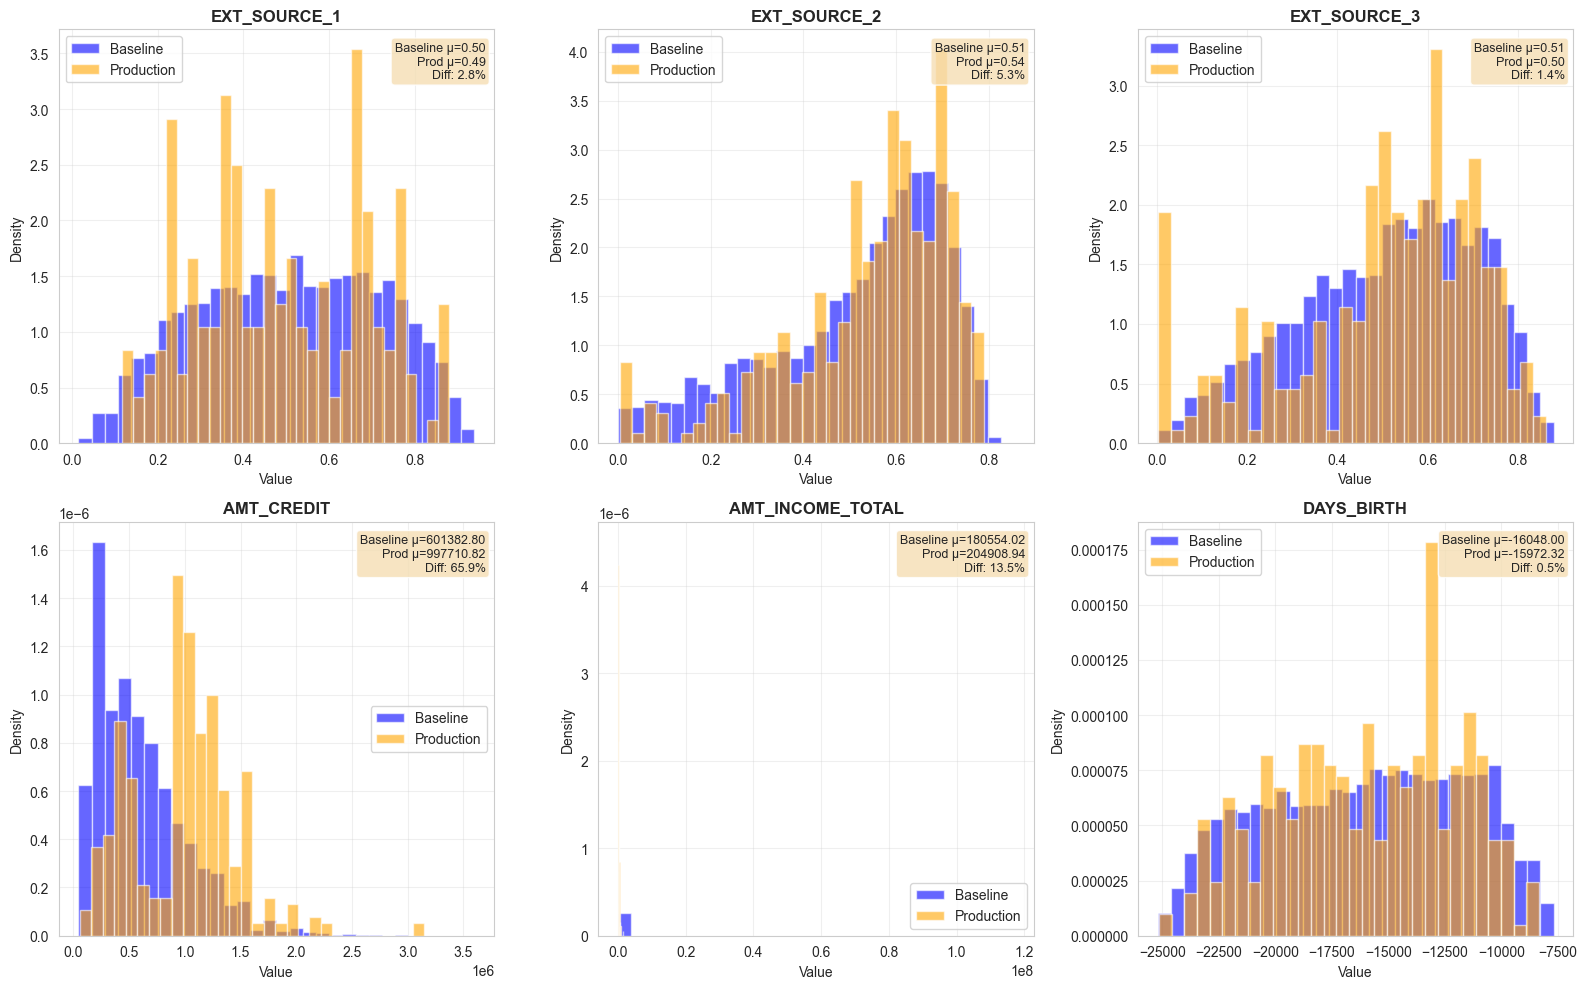

✓ Feature distributions plot saved


In [27]:
if len(production_df_aligned) > 0:
    # Top 6 features to analyze
    key_features = [
        'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
        'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH'
    ]
    
    # Filter to only numeric features that exist
    available_features = []
    for f in key_features:
        if f in production_df_aligned.columns:
            if production_df_aligned[f].dtype != 'object' and reference_df_aligned[f].dtype != 'object':
                available_features.append(f)
    
    if available_features:
        print(f"📊 Analyzing {len(available_features)} key features...")
        
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        axes = axes.flatten()
        
        for idx, feature in enumerate(available_features):
            ax = axes[idx]
            
            # Get data
            baseline_data = reference_df_aligned[feature].dropna()
            production_data = production_df_aligned[feature].dropna()
            
            # Plot histograms
            ax.hist(baseline_data, bins=30, alpha=0.6, label='Baseline', color='blue', density=True)
            ax.hist(production_data, bins=30, alpha=0.6, label='Production', color='orange', density=True)
            
            ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Value')
            ax.set_ylabel('Density')
            ax.legend()
            ax.grid(True, alpha=0.3)
            
            # Statistics
            baseline_mean = baseline_data.mean()
            production_mean = production_data.mean()
            percent_diff = abs(production_mean - baseline_mean) / abs(baseline_mean) * 100 if baseline_mean != 0 else 0
            
            info_text = f"Baseline μ={baseline_mean:.2f}\nProd μ={production_mean:.2f}\nDiff: {percent_diff:.1f}%"
            ax.text(0.98, 0.97, info_text, transform=ax.transAxes, 
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                   fontsize=9)
        
        # Hide unused subplots
        for idx in range(len(available_features), 6):
            axes[idx].set_visible(False)
        
        plt.tight_layout()
        plt.savefig('../reports/feature_distributions.png', dpi=100, bbox_inches='tight')
        plt.show()
        print(f"✓ Feature distributions plot saved")
    else:
        print(f"⚠️  No numeric key features found in production data")
else:
    print("⚠️  No production data available for analysis")

## 8. Métriques Opérationnelles

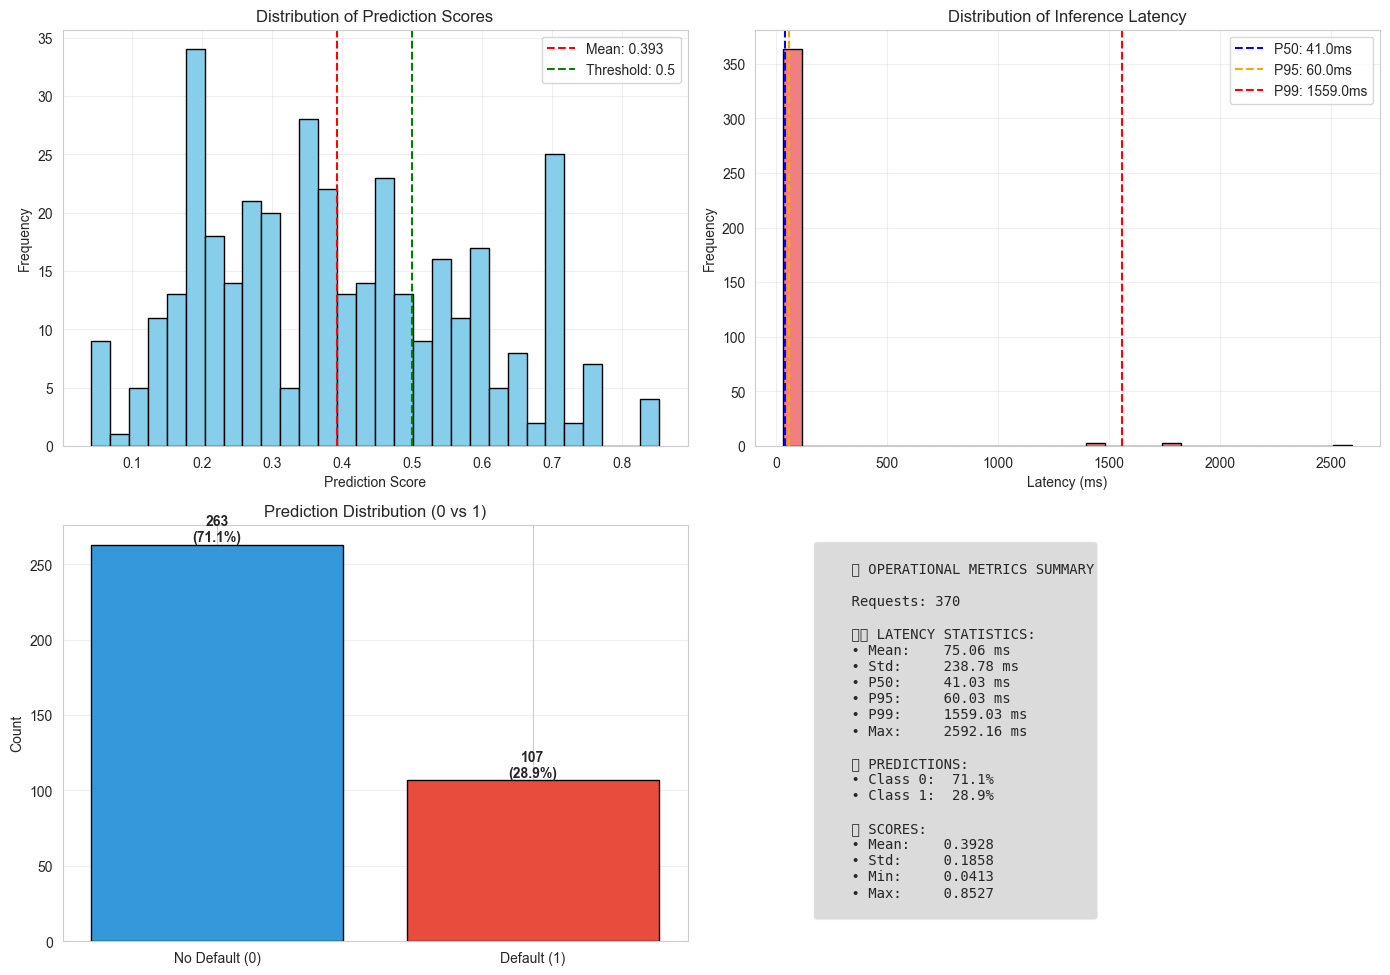

✓ Operational metrics visualization saved


In [28]:
if len(production_metrics_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Score distribution
    ax = axes[0, 0]
    ax.hist(production_metrics_df['score'], bins=30, color='skyblue', edgecolor='black')
    ax.axvline(production_metrics_df['score'].mean(), color='red', linestyle='--', label=f"Mean: {production_metrics_df['score'].mean():.3f}")
    ax.axvline(0.5, color='green', linestyle='--', label="Threshold: 0.5")
    ax.set_xlabel('Prediction Score')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Prediction Scores')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Latency distribution with percentiles
    ax = axes[0, 1]
    latencies = production_metrics_df['inference_time_ms'].dropna()
    ax.hist(latencies, bins=30, color='lightcoral', edgecolor='black')
    p50 = latencies.quantile(0.50)
    p95 = latencies.quantile(0.95)
    p99 = latencies.quantile(0.99)
    ax.axvline(p50, color='blue', linestyle='--', label=f"P50: {p50:.1f}ms")
    ax.axvline(p95, color='orange', linestyle='--', label=f"P95: {p95:.1f}ms")
    ax.axvline(p99, color='red', linestyle='--', label=f"P99: {p99:.1f}ms")
    ax.set_xlabel('Latency (ms)')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Inference Latency')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Prediction distribution (0 vs 1)
    ax = axes[1, 0]
    pred_counts = production_metrics_df['prediction'].value_counts().sort_index()
    colors = ['#3498db', '#e74c3c']
    bars = ax.bar(['No Default (0)', 'Default (1)'], pred_counts.values, color=colors, edgecolor='black')
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{int(height)}\n({height/len(production_metrics_df)*100:.1f}%)',
               ha='center', va='bottom', fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_title('Prediction Distribution (0 vs 1)')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 4. Metrics summary text
    ax = axes[1, 1]
    ax.axis('off')
    
    summary_text = f"""
    📊 OPERATIONAL METRICS SUMMARY
    
    Requests: {len(production_metrics_df)}
    
    ⏱️ LATENCY STATISTICS:
    • Mean:    {latencies.mean():.2f} ms
    • Std:     {latencies.std():.2f} ms  
    • P50:     {p50:.2f} ms
    • P95:     {p95:.2f} ms
    • P99:     {p99:.2f} ms
    • Max:     {latencies.max():.2f} ms
    
    🎯 PREDICTIONS:
    • Class 0:  {(pred_counts.get(0, 0) / len(production_metrics_df) * 100):.1f}%
    • Class 1:  {(pred_counts.get(1, 0) / len(production_metrics_df) * 100):.1f}%
    
    📈 SCORES:
    • Mean:    {production_metrics_df['score'].mean():.4f}
    • Std:     {production_metrics_df['score'].std():.4f}
    • Min:     {production_metrics_df['score'].min():.4f}
    • Max:     {production_metrics_df['score'].max():.4f}
    """
    
    ax.text(0.1, 0.95, summary_text, transform=ax.transAxes,
           verticalalignment='top', fontfamily='monospace', fontsize=10,
           bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('../reports/operational_metrics.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Operational metrics visualization saved")
else:
    print(f"⚠️  No metrics data available for operational analysis")

## 9. Conclusion et Recommandations

In [29]:
if 'drift_df' in locals() and len(drift_df) > 0:
    print("\n" + "="*80)
    print("📊 DETAILED DRIFT ANALYSIS")
    print("="*80)
    
    # Summary statistics
    print(f"\n🔢 DRIFT STATISTICS:")
    print(f"  Total numeric features: {len(drift_df)}")
    print(f"  Features with drift > 5%: {(drift_df['diff_percent'] > 5).sum()}")
    print(f"  Features with drift > 10%: {(drift_df['diff_percent'] > 10).sum()}")
    print(f"  Features with drift > 20%: {(drift_df['diff_percent'] > 20).sum()}")
    print(f"  Features with drift > 50%: {(drift_df['diff_percent'] > 50).sum()}")
    
    # Critical drift features (> 20%)
    critical_drift = drift_df[drift_df['diff_percent'] > 20].sort_values('diff_percent', ascending=False)
    if len(critical_drift) > 0:
        print(f"\n🚨 CRITICAL DRIFT FEATURES (> 20%):")
        for idx, row in critical_drift.head(15).iterrows():
            print(f"  • {row['feature']:30} | Drift: {row['diff_percent']:7.2f}% | Base: {row['baseline_mean']:10.4f} → Prod: {row['production_mean']:10.4f}")
    
    # High drift features (10-20%)
    high_drift = drift_df[(drift_df['diff_percent'] >= 10) & (drift_df['diff_percent'] <= 20)].sort_values('diff_percent', ascending=False)
    if len(high_drift) > 0:
        print(f"\n⚠️  HIGH DRIFT FEATURES (10-20%):")
        print(f"  Count: {len(high_drift)} features")
        print(f"  Sample:")
        for idx, row in high_drift.head(5).iterrows():
            print(f"    • {row['feature']:30} | Drift: {row['diff_percent']:7.2f}%")
    
    # Moderate drift features (5-10%)
    moderate_drift = drift_df[(drift_df['diff_percent'] >= 5) & (drift_df['diff_percent'] < 10)].sort_values('diff_percent', ascending=False)
    if len(moderate_drift) > 0:
        print(f"\n⚡ MODERATE DRIFT FEATURES (5-10%):")
        print(f"  Count: {len(moderate_drift)} features")
    
    # Stable features
    stable = drift_df[drift_df['diff_percent'] < 5]
    print(f"\n✅ STABLE FEATURES (< 5%): {len(stable)} features")
    
    # Volatility analysis
    print(f"\n📈 VOLATILITY ANALYSIS (Std deviation change):")
    drift_df['volatility_change'] = (drift_df['production_std'] - drift_df['baseline_std']) / (drift_df['baseline_std'] + 1e-6) * 100
    high_volatility = drift_df.nlargest(5, 'volatility_change')
    for idx, row in high_volatility.iterrows():
        print(f"  • {row['feature']:30} | Vol change: {row['volatility_change']:7.2f}% | Base σ: {row['baseline_std']:.4f} → Prod σ: {row['production_std']:.4f}")
    
    print(f"\n" + "="*80)
else:
    print("⚠️  No drift data available for analysis")


📊 DETAILED DRIFT ANALYSIS

🔢 DRIFT STATISTICS:
  Total numeric features: 130
  Features with drift > 5%: 98
  Features with drift > 10%: 77
  Features with drift > 20%: 60
  Features with drift > 50%: 27

🚨 CRITICAL DRIFT FEATURES (> 20%):
  • NONLIVINGAPARTMENTS_MEDI       | Drift:  188.20% | Base:     0.0097 → Prod:     0.0281
  • NONLIVINGAPARTMENTS_AVG        | Drift:  187.23% | Base:     0.0098 → Prod:     0.0283
  • NONLIVINGAPARTMENTS_MODE       | Drift:  174.07% | Base:     0.0093 → Prod:     0.0255
  • FLAG_DOCUMENT_7                | Drift:  100.00% | Base:     0.0002 → Prod:     0.0000
  • FLAG_DOCUMENT_19               | Drift:  100.00% | Base:     0.0008 → Prod:     0.0000
  • FLAG_DOCUMENT_2                | Drift:  100.00% | Base:     0.0001 → Prod:     0.0000
  • FLAG_DOCUMENT_15               | Drift:  100.00% | Base:     0.0018 → Prod:     0.0000
  • FLAG_DOCUMENT_20               | Drift:  100.00% | Base:     0.0004 → Prod:     0.0000
  • FLAG_DOCUMENT_12           

## 10. Analyse Détaillée de la Qualité des Données

In [30]:
if 'quality_df' in locals() and len(quality_df) > 0:
    print("\n" + "="*80)
    print("📋 DETAILED DATA QUALITY ANALYSIS")
    print("="*80)
    
    # Overall quality metrics
    print(f"\n✅ QUALITY OVERVIEW:")
    print(f"  Total features: {len(quality_df)}")
    print(f"  Baseline missing average: {quality_df['baseline_missing_pct'].mean():.2f}%")
    print(f"  Production missing average: {quality_df['production_missing_pct'].mean():.2f}%")
    print(f"  Features with NEW missing values: {(quality_df['missing_increase'] > 0).sum()}")
    print(f"  Features with NO missing values: {(quality_df['production_missing_pct'] == 0).sum()}")
    
    # Features with increased missingness
    increased_missing = quality_df[quality_df['missing_increase'] > 0].sort_values('missing_increase', ascending=False)
    if len(increased_missing) > 0:
        print(f"\n⚠️  FEATURES WITH INCREASED MISSING VALUES:")
        for idx, row in increased_missing.head(10).iterrows():
            print(f"  • {row['feature']:30} | Baseline: {row['baseline_missing_pct']:6.2f}% → Production: {row['production_missing_pct']:6.2f}% (Δ +{row['missing_increase']:6.2f}%)")
    
    # Features with NO missing values
    perfect_quality = quality_df[quality_df['production_missing_pct'] == 0]
    print(f"\n✓ FEATURES WITH PERFECT DATA QUALITY (0% missing):")
    print(f"  Count: {len(perfect_quality)}")
    
    # Type consistency check
    print(f"\n🔍 DATA TYPE CONSISTENCY:")
    dtype_mismatch = quality_df[quality_df['baseline_dtype'] != quality_df['production_dtype']]
    if len(dtype_mismatch) > 0:
        print(f"  ⚠️  Type mismatch detected in {len(dtype_mismatch)} features:")
        for idx, row in dtype_mismatch.iterrows():
            print(f"    • {row['feature']:30} | Baseline: {row['baseline_dtype']:10} → Production: {row['production_dtype']:10}")
    else:
        print(f"  ✓ No type mismatches - all dtypes consistent")
    
    # High missing percentage in production
    high_missing = quality_df[quality_df['production_missing_pct'] > 5].sort_values('production_missing_pct', ascending=False)
    if len(high_missing) > 0:
        print(f"\n⚠️  FEATURES WITH HIGH MISSING % (> 5% in production):")
        for idx, row in high_missing.head(10).iterrows():
            print(f"  • {row['feature']:30} | Missing: {row['production_missing_pct']:6.2f}%")
    
    # Recommendation
    print(f"\n💡 RECOMMENDATIONS:")
    if len(increased_missing) > 0:
        top_missing = increased_missing.iloc[0]
        print(f"  1. Investigate {top_missing['feature']} - missing increased by {top_missing['missing_increase']:.2f}%")
    if len(dtype_mismatch) > 0:
        print(f"  2. Check data pipeline - {len(dtype_mismatch)} features changed type")
    if len(high_missing) > 0:
        print(f"  3. Handle missing values - {len(high_missing)} features have > 5% missingness")
    print(f"  4. Verify data source consistency between baseline and production")
    
    print(f"\n" + "="*80)
else:
    print("⚠️  No quality data available for analysis")


📋 DETAILED DATA QUALITY ANALYSIS

✅ QUALITY OVERVIEW:
  Total features: 146
  Baseline missing average: 24.51%
  Production missing average: 24.07%
  Features with NEW missing values: 33
  Features with NO missing values: 62

⚠️  FEATURES WITH INCREASED MISSING VALUES:
  • EMERGENCYSTATE_MODE            | Baseline:  47.24% → Production:  49.19% (Δ +  1.95%)
  • LANDAREA_AVG                   | Baseline:  59.18% → Production:  60.54% (Δ +  1.36%)
  • LANDAREA_MEDI                  | Baseline:  59.18% → Production:  60.54% (Δ +  1.36%)
  • LANDAREA_MODE                  | Baseline:  59.18% → Production:  60.54% (Δ +  1.36%)
  • installments_sum               | Baseline:   5.42% → Production:   6.76% (Δ +  1.34%)
  • installments_count             | Baseline:   5.42% → Production:   6.76% (Δ +  1.34%)
  • payment_sum                    | Baseline:   5.42% → Production:   6.76% (Δ +  1.34%)
  • installments_mean              | Baseline:   5.42% → Production:   6.76% (Δ +  1.34%)
  • payme

## 11. Analyse Détaillée du Data Drift

In [ ]:
print("\n" + "="*80)
print("📊 EXECUTIVE SUMMARY — MONITORING DASHBOARD")
print("="*80)

if len(production_df_aligned) > 0:
    print(f"\n📈 DATA COVERAGE:")
    print(f"  Baseline samples: {len(reference_df_aligned):,}")
    print(f"  Production samples: {len(production_df_aligned):,}")
    print(f"  Features analyzed: {len(common_cols)} (130 numeric + 16 categorical)")
    
    # Drift Summary
    if 'drift_df' in locals():
        critical = (drift_df['diff_percent'] > 20).sum()
        high = ((drift_df['diff_percent'] >= 10) & (drift_df['diff_percent'] <= 20)).sum()
        moderate = ((drift_df['diff_percent'] >= 5) & (drift_df['diff_percent'] < 10)).sum()
        
        print(f"\n🚨 DRIFT ALERT LEVEL:")
        if critical > 15:
            print(f"  🔴 CRITICAL: {critical} features with drift > 20%")
        elif critical > 5:
            print(f"  🟠 HIGH: {critical} features with drift > 20%")
        else:
            print(f"  🟡 MEDIUM: {critical} features with drift > 20%")
        
        print(f"  Breakdown:")
        print(f"    Critical (>20%): {critical} features")
        print(f"    High (10-20%): {high} features")
        print(f"    Moderate (5-10%): {moderate} features")
        print(f"    Stable (<5%): {len(drift_df) - critical - high - moderate} features")
        
        # Top issue
        if len(drift_df) > 0:
            top_issue = drift_df.iloc[0]
            print(f"\n  Top drift issue:")
            print(f"    {top_issue['feature']}: {top_issue['diff_percent']:.2f}% drift")
    
    # Quality Summary
    if 'quality_df' in locals():
        new_missing = (quality_df['missing_increase'] > 0).sum()
        high_missing_count = (quality_df['production_missing_pct'] > 5).sum()
        
        print(f"\n🛡️  DATA QUALITY ALERT LEVEL:")
        if high_missing_count > 20 or new_missing > 50:
            print(f"  🔴 CRITICAL: High missing value issues")
        elif high_missing_count > 10 or new_missing > 20:
            print(f"  🟠 HIGH: Significant data quality degradation")
        else:
            print(f"  🟢 GOOD: Data quality generally stable")
        
        print(f"  Issues detected:")
        print(f"    Features with new missing: {new_missing}")
        print(f"    Features with >5% missing: {high_missing_count}")
    
    # Performance
    if len(production_metrics_df) > 0:
        print(f"\n⚡ MODEL PERFORMANCE:")
        print(f"  Predictions: {len(production_metrics_df):,} total")
        print(f"  Default rate: {(production_metrics_df['prediction'].sum() / len(production_metrics_df) * 100):.2f}%")
        print(f"  Avg latency: {production_metrics_df['inference_time_ms'].mean():.2f}ms")
        print(f"  P95 latency: {production_metrics_df['inference_time_ms'].quantile(0.95):.2f}ms")
    
    # Final Recommendation
    print(f"\n✅ ACTION ITEMS:")
    if critical > 10:
        print(f"  🔴 PRIORITY 1: Retrain model - critical drift detected")
    elif critical > 5:
        print(f"  🟠 PRIORITY 1: Schedule retraining - significant drift detected")
    else:
        print(f"  🟡 PRIORITY 2: Monitor drift trends - continue tracking")
    
    if new_missing > 30:
        print(f"  🔴 PRIORITY 1: Fix data pipeline - increasing missing values")
    elif new_missing > 10:
        print(f"  🟠 PRIORITY 2: Investigate data source inconsistencies")
    
    print(f"\n📁 GENERATED REPORTS:")
    print(f"  ✓ reports/drift_report.csv - Detailed drift statistics")
    print(f"  ✓ reports/quality_report.csv - Data quality metrics")
    print(f"  ✓ reports/feature_distributions.png - 6 key features visualization")
    print(f"  ✓ reports/operational_metrics.png - Performance dashboard")
    
else:
    print(f"\n⚠️  NO PRODUCTION DATA - Run traffic simulation first:")
    print(f"  $ uv run python scripts/simulate_traffic.py --n-requests 1000 --drift")

print(f"\n" + "="*80)
print(f"✓ Full analysis complete at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"="*80 + "\n")


📊 EXECUTIVE SUMMARY — MONITORING DASHBOARD

📈 DATA COVERAGE:
  Baseline samples: 10,000
  Production samples: 370
  Features analyzed: 146 (130 numeric + 16 categorical)

🚨 DRIFT ALERT LEVEL:
  🔴 CRITICAL: 60 features with drift > 20%
  Breakdown:
    Critical (>20%): 60 features
    High (10-20%): 17 features
    Moderate (5-10%): 21 features
    Stable (<5%): 32 features

  Top drift issue:
    NONLIVINGAPARTMENTS_MEDI: 188.20% drift

🛡️  DATA QUALITY ALERT LEVEL:
  🔴 CRITICAL: High missing value issues
  Issues detected:
    Features with new missing: 33
    Features with >5% missing: 83

⚡ MODEL PERFORMANCE:
  Predictions: 370 total
  Default rate: 28.92%
  Avg latency: 75.06ms
  P95 latency: 60.03ms

✅ ACTION ITEMS:
  🔴 PRIORITY 1: Retrain model - critical drift detected
  🔴 PRIORITY 1: Fix data pipeline - increasing missing values

📁 GENERATED REPORTS:
  ✓ reports/drift_report.csv - Detailed drift statistics
  ✓ reports/quality_report.csv - Data quality metrics
  ✓ reports/featu

INVESTIGATION DETAILS

1. TOP 10 FEATURES BY DRIFT MAGNITUDE:

                 Feature Drift % Baseline Mean Production Mean
NONLIVINGAPARTMENTS_MEDI 188.20%      0.009735        0.028058
 NONLIVINGAPARTMENTS_AVG 187.23%      0.009836        0.028251
NONLIVINGAPARTMENTS_MODE 174.07%      0.009295        0.025474
         FLAG_DOCUMENT_7 100.00%      0.000200        0.000000
        FLAG_DOCUMENT_19 100.00%      0.000800        0.000000
         FLAG_DOCUMENT_2 100.00%      0.000100        0.000000
        FLAG_DOCUMENT_15 100.00%      0.001800        0.000000
        FLAG_DOCUMENT_20 100.00%      0.000400        0.000000
        FLAG_DOCUMENT_12 100.00%      0.000100        0.000000
        FLAG_DOCUMENT_21 100.00%      0.000600        0.000000


2. AMT_CREDIT DISTRIBUTION ANALYSIS (Bias Verification):

Baseline AMT_CREDIT:
  Count: 10000, Mean: 601382.80, Median: 512721.00, Std: 405995.92
  Percentiles: 25%=270000.00, 75%=810000.00, 95%=1350000.00

Production AMT_CREDIT:
  Count: 370

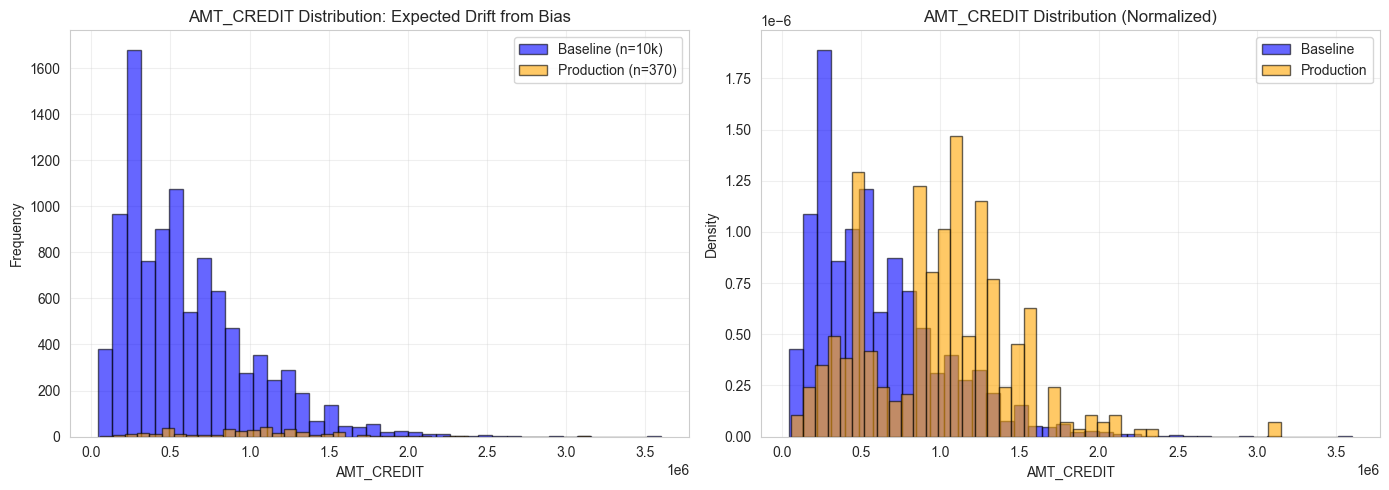


  Visualization saved to reports/amt_credit_drift_verification.png
  Interpretation: Production shows higher concentration in higher AMT_CREDIT range,
  consistent with intentional bias in simulate_traffic.py --drift mode.


3. FLAG_DOCUMENT_X FREQUENCY ANALYSIS (Small Sample Artifact):

Top 10 FLAGS by baseline frequency:

Flag                      Baseline %      Production %    Diff %         
----------------------------------------------------------------------
FLAG_DOCUMENT_3                   70.69%         72.70%          2.01%
FLAG_DOCUMENT_6                    8.65%          8.11%         -0.54%
FLAG_DOCUMENT_8                    8.50%         10.00%          1.50%
FLAG_DOCUMENT_5                    1.50%          0.54%         -0.96%
FLAG_DOCUMENT_16                   1.07%          0.27%         -0.80%
FLAG_DOCUMENT_18                   0.86%          0.27%         -0.59%
FLAG_DOCUMENT_9                    0.48%          0.81%          0.33%
FLAG_DOCUMENT_11               

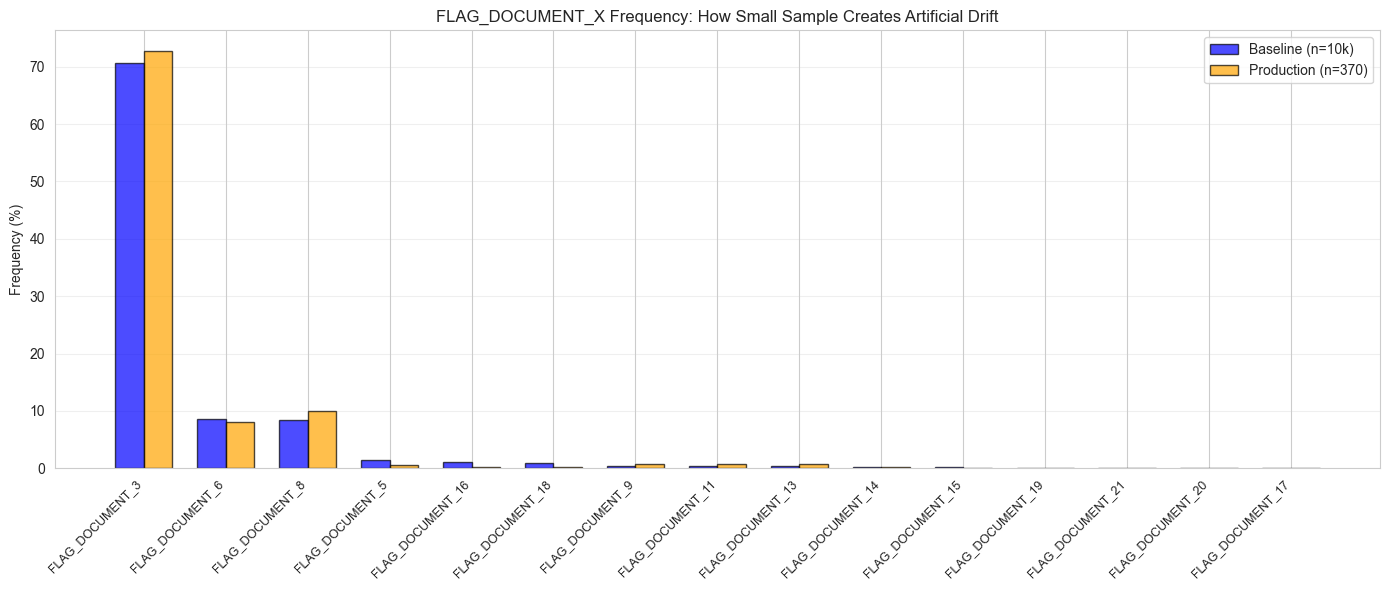


  Visualization saved to reports/flag_document_small_sample_analysis.png
  Interpretation: Flags with < 1% baseline frequency show large relative changes
  due to binomial variance with n=370. Not representative of real drift.



In [ ]:
import warnings
warnings.filterwarnings('ignore')

if 'drift_df' in locals() and len(drift_df) > 0:
    print("="*80)
    print("INVESTIGATION DETAILS")
    print("="*80)
    
    # 1. Top 10 features by drift
    print("\n1. TOP 10 FEATURES BY DRIFT MAGNITUDE:\n")
    top_10_drift = drift_df.head(10)[['feature', 'diff_percent', 'baseline_mean', 'production_mean']].copy()
    top_10_drift.columns = ['Feature', 'Drift %', 'Baseline Mean', 'Production Mean']
    top_10_drift['Drift %'] = top_10_drift['Drift %'].apply(lambda x: f"{x:.2f}%")
    top_10_drift['Baseline Mean'] = top_10_drift['Baseline Mean'].apply(lambda x: f"{x:.6f}")
    top_10_drift['Production Mean'] = top_10_drift['Production Mean'].apply(lambda x: f"{x:.6f}")
    print(top_10_drift.to_string(index=False))
    
    # 2. AMT_CREDIT focus
    print("\n\n2. AMT_CREDIT DISTRIBUTION ANALYSIS (Bias Verification):\n")
    if 'AMT_CREDIT' in reference_df_aligned.columns and 'AMT_CREDIT' in production_df_aligned.columns:
        amt_baseline = reference_df_aligned['AMT_CREDIT'].dropna()
        amt_production = production_df_aligned['AMT_CREDIT'].dropna()
        
        print(f"Baseline AMT_CREDIT:")
        print(f"  Count: {len(amt_baseline)}, Mean: {amt_baseline.mean():.2f}, Median: {amt_baseline.median():.2f}, Std: {amt_baseline.std():.2f}")
        print(f"  Percentiles: 25%={amt_baseline.quantile(0.25):.2f}, 75%={amt_baseline.quantile(0.75):.2f}, 95%={amt_baseline.quantile(0.95):.2f}")
        
        print(f"\nProduction AMT_CREDIT:")
        print(f"  Count: {len(amt_production)}, Mean: {amt_production.mean():.2f}, Median: {amt_production.median():.2f}, Std: {amt_production.std():.2f}")
        print(f"  Percentiles: 25%={amt_production.quantile(0.25):.2f}, 75%={amt_production.quantile(0.75):.2f}, 95%={amt_production.quantile(0.95):.2f}")
        
        # Visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        ax1.hist(amt_baseline, bins=40, alpha=0.6, label='Baseline (n=10k)', color='blue', edgecolor='black')
        ax1.hist(amt_production, bins=40, alpha=0.6, label='Production (n=370)', color='orange', edgecolor='black')
        ax1.set_xlabel('AMT_CREDIT')
        ax1.set_ylabel('Frequency')
        ax1.set_title('AMT_CREDIT Distribution: Expected Drift from Bias')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Density plot for clarity
        ax2.hist(amt_baseline, bins=40, alpha=0.6, label='Baseline', color='blue', density=True, edgecolor='black')
        ax2.hist(amt_production, bins=40, alpha=0.6, label='Production', color='orange', density=True, edgecolor='black')
        ax2.set_xlabel('AMT_CREDIT')
        ax2.set_ylabel('Density')
        ax2.set_title('AMT_CREDIT Distribution (Normalized)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('../reports/amt_credit_drift_verification.png', dpi=100, bbox_inches='tight')
        plt.show()
        print(f"\n  Visualization saved to reports/amt_credit_drift_verification.png")
        print(f"  Interpretation: Production shows higher concentration in higher AMT_CREDIT range,")
        print(f"  consistent with intentional bias in simulate_traffic.py --drift mode.")
    
    # 3. FLAG_DOCUMENT analysis
    print("\n\n3. FLAG_DOCUMENT_X FREQUENCY ANALYSIS (Small Sample Artifact):\n")
    flag_features = [col for col in common_cols if col.startswith('FLAG_DOCUMENT')]
    if flag_features:
        flag_baseline_freq = []
        flag_production_freq = []
        flag_names = []
        
        for flag in sorted(flag_features):
            baseline_freq = (reference_df_aligned[flag] == 1).sum() / len(reference_df_aligned) * 100
            production_freq = (production_df_aligned[flag] == 1).sum() / len(production_df_aligned) * 100
            flag_baseline_freq.append(baseline_freq)
            flag_production_freq.append(production_freq)
            flag_names.append(flag)
        
        # Show top 10 flags by baseline frequency
        flag_data = list(zip(flag_names, flag_baseline_freq, flag_production_freq))
        flag_data.sort(key=lambda x: x[1], reverse=True)
        
        print(f"Top 10 FLAGS by baseline frequency:\n")
        print(f"{'Flag':<25} {'Baseline %':<15} {'Production %':<15} {'Diff %':<15}")
        print("-" * 70)
        for name, base_freq, prod_freq in flag_data[:10]:
            diff = prod_freq - base_freq
            print(f"{name:<25} {base_freq:>13.2f}% {prod_freq:>13.2f}% {diff:>13.2f}%")
        
        # Visualization
        fig, ax = plt.subplots(figsize=(14, 6))
        
        x = np.arange(len(flag_data[:15]))
        width = 0.35
        
        baseline_vals = [x[1] for x in flag_data[:15]]
        production_vals = [x[2] for x in flag_data[:15]]
        names = [x[0] for x in flag_data[:15]]
        
        bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline (n=10k)', color='blue', alpha=0.7, edgecolor='black')
        bars2 = ax.bar(x + width/2, production_vals, width, label='Production (n=370)', color='orange', alpha=0.7, edgecolor='black')
        
        ax.set_ylabel('Frequency (%)')
        ax.set_title('FLAG_DOCUMENT_X Frequency: How Small Sample Creates Artificial Drift')
        ax.set_xticks(x)
        ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig('../reports/flag_document_small_sample_analysis.png', dpi=100, bbox_inches='tight')
        plt.show()
        
        print(f"\n  Visualization saved to reports/flag_document_small_sample_analysis.png")
        print(f"  Interpretation: Flags with < 1% baseline frequency show large relative changes")
        print(f"  due to binomial variance with n=370. Not representative of real drift.")
    
    print("\n" + "="*80)
else:
    print("Drift data not available for investigation")